# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [35]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ────────────────────────────────────────────────────────────────
#URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv("AB_NYC_2019.csv")

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Data loaded successfully!
Shape: 48,895 rows x 16 columns


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


1.  Numerical columns: 10

    Categorical columns: 6 

2. Missing values in several columns

  last_review stored as text instead of datetime

  

In [36]:
# Your code here
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [38]:

#total numerical columns
df.select_dtypes(include= ['int64', 'float64']).columns

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [39]:
#total categorical columns
df.select_dtypes(include=['object']).columns

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')

In [40]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [41]:
# statistics including categorical columns
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


**✍️ Your Interpretation:**  
*(Write here)*


### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


In [42]:
# Your code here
df.isnull().sum()


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [43]:
df = df.dropna(subset=['name', 'host_name'])

In [44]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [45]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [46]:
df['last_review'] = df['last_review'].fillna(0)

In [47]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

**✍️ Your Interpretation:**  
*(Write here)*


### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [48]:
# Your code here
df.duplicated().sum()

np.int64(0)

In [49]:
df['id'].duplicated().sum()

np.int64(0)

In [60]:
print("After removing duplicates, new shape:", df.shape) 

After removing duplicates, new shape: (48858, 16)


**✍️ Your Interpretation:**  
*(Write here)*


---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


In [61]:
# Your code here
df.head(1)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19 00:00:00,0.21,6,365


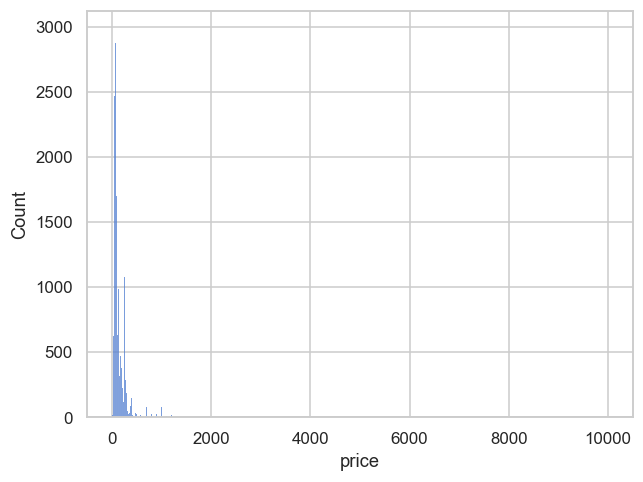

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'])
plt.show()

In [64]:
(df['price'] == 0).sum()

np.int64(11)

In [72]:
# Remove zero-priced listings
df = df[df['price'] > 0]

In [71]:
(df['price'] == 0).sum()

np.int64(0)

After Removing zero listed price


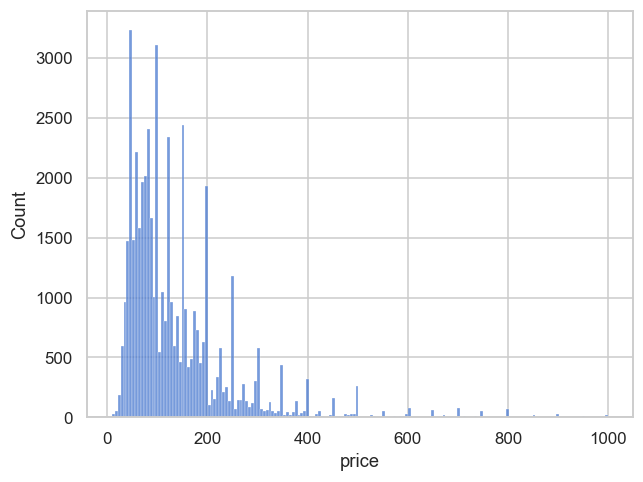

In [73]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print('After Removing zero listed price')
df['after remove zero listed price'] =(df['price'])

sns.histplot(df['price'])
plt.show()

In [74]:
df = df[df['price'] < 500]

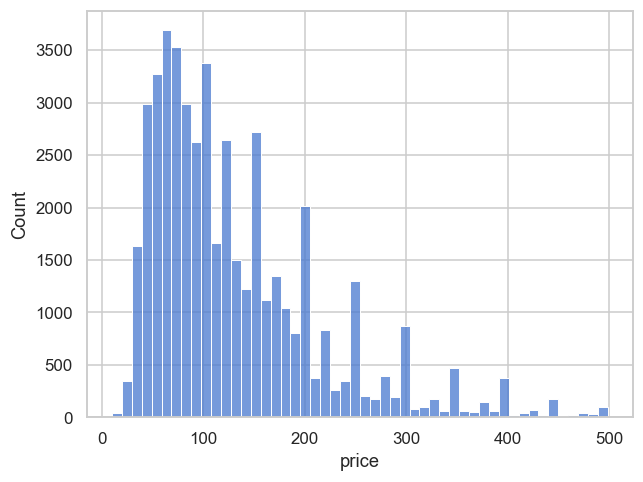

In [76]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print()
df['price'] =(df['price'])

sns.histplot(df['price'], bins=50)
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


In [51]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


In [52]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


In [53]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


In [54]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


In [55]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


In [56]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


In [57]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


In [58]:
# Your code here


**✍️ Your Interpretation:**  
*(Write here)*


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnings
*(Write here)*

### Manhattan Investor
*(Write here)*

### Brooklyn Investor
*(Write here)*

### Recommendation for Undecided Investor
*(Write here)*

### What I Would Investigate Next
*(Write here)*

---


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


In [59]:
# Bonus code here (optional)


**✍️ Bonus Interpretation:**  
*(Write here)*


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
